# Retail Store Sales — Revenue Driver Analysis

## Objective

This analysis examines transaction-level retail data to identify the
factors associated with revenue performance, with particular focus on
category performance, sales volume, pricing and discounts.

### Business Questions

- Which categories generate the highest revenue?
- How do sales volume and price relate to revenue?
- Do discounts influence sales and revenue?
- What factors explain differences in category revenue?
- What additional data would strengthen the analysis?

## 1. Data Loading and Initial Assessment

The dataset was loaded into Python and assessed for structure, completeness,
duplicate records, data types, and consistency with basic transaction-level
business rules.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/valentinekimotho/retail-store-dataset-project/retail_store_sales.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (12575, 11)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [2]:
# Inspect dataset structure and data quality

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Discount Applied']

Data types:
Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied     object
dtype: object

Missing values:
Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

Duplicate rows: 0


In [3]:
# Validate the transaction-level revenue calculation
# Business rule: Total Spent = Price Per Unit × Quantity

df["Calculated Total"] = (
    df["Price Per Unit"] * df["Quantity"]
)

df[
    ["Price Per Unit", "Quantity", "Total Spent", "Calculated Total"]
].head(10)

,Price Per Unit,Quantity,Total Spent,Calculated Total
0,18.5,10.0,185.0,185.0
1,29.0,9.0,261.0,261.0
2,21.5,2.0,43.0,43.0
3,27.5,9.0,247.5,247.5
4,12.5,7.0,87.5,87.5
5,NaN,10.0,200.0,NaN
6,5.0,8.0,40.0,40.0
7,33.5,NaN,NaN,NaN
8,27.5,1.0,27.5,27.5
9,36.5,3.0,109.5,109.5


In [4]:
# Convert Transaction Date from object to datetime

df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"]
)

print("Transaction Date dtype:", df["Transaction Date"].dtype)

Transaction Date dtype: datetime64[ns]


## 2. Data Cleaning

A copy of the original dataset was created before cleaning.

Cleaning decisions were based on whether missing information could be
reliably reconstructed without introducing unsupported assumptions.

In [5]:
# Remove temporary validation column
df.drop(columns="Calculated Total", inplace=True)

In [6]:
# Create a working copy
df_clean = df.copy()

# Review missing values before cleaning
df_clean.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [7]:
# Reconstruct missing Total Spent values where
# both Price Per Unit and Quantity are available

df_clean.loc[
    df_clean["Total Spent"].isnull(),
    "Total Spent"
] = (
    df_clean["Price Per Unit"] *
    df_clean["Quantity"]
)

In [8]:
# Check whether missing Total Spent values remain

df_clean["Total Spent"].isnull().sum()

np.int64(604)

In [9]:
# Remove records with missing essential fields
df_clean = df_clean.dropna(
    subset=["Item", "Quantity", "Total Spent"]
)

In [10]:
# Validate the cleaned dataset

print("Remaining missing values:")
print(df_clean.isnull().sum())

print("\nCleaned dataset shape:", df_clean.shape)

Remaining missing values:
Transaction ID         0
Customer ID            0
Category               0
Item                   0
Price Per Unit         0
Quantity               0
Total Spent            0
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    3783
dtype: int64

Cleaned dataset shape: (11362, 11)


### Cleaning Outcome

Missing `Total Spent` values that could be reliably reconstructed were
calculated using the relationship between price and quantity.

Records with missing essential information that could not be reliably
reconstructed were removed.

The dataset was reduced from **12,575 rows to 11,362 rows**, while retaining
the original **12 columns**.

## 3. Overall Revenue Performance

Revenue performance was first compared across product categories to identify
the strongest revenue-generating segments. Quantity sold, average transaction
value and revenue per unit were then considered to understand what was driving
differences in category performance.

In [11]:
# Calculate key performance metrics by category

category_performance = (
    df_clean.groupby("Category")
    .agg(
        Revenue=("Total Spent", "sum"),
        Quantity_Sold=("Quantity", "sum"),
        Avg_Transaction_Value=("Total Spent", "mean"),
        Revenue_per_Unit=("Total Spent", "sum")
    )
    .reset_index()
)

# Calculate revenue per unit
category_performance["Revenue_per_Unit"] = (
    category_performance["Revenue"]
    / category_performance["Quantity_Sold"]
)

# Sort by revenue
category_performance = category_performance.sort_values(
    "Revenue",
    ascending=False
)

category_performance

,Category,Revenue,Quantity_Sold,Avg_Transaction_Value,Revenue_per_Unit
1,Butchers,197426.0,7774.0,138.934553,25.395678
3,Electric household essentials,192441.5,7897.0,133.918928,24.368938
0,Beverages,187978.5,7974.0,131.729853,23.573928
5,Furniture,186527.0,8083.0,127.758219,23.076457
4,Food,184645.0,7925.0,129.484572,23.299054
2,Computers and electric accessories,180902.5,7832.0,129.493558,23.097868
7,Patisserie,172330.5,7515.0,125.880570,22.931537
6,Milk Products,170747.5,7889.0,119.822807,21.643744


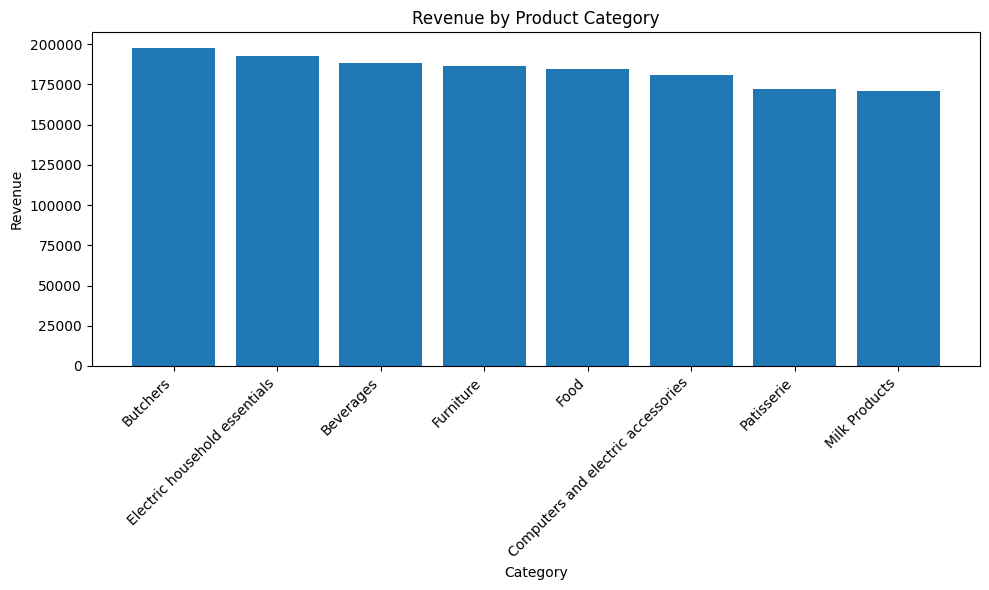

In [12]:
# Revenue by category

plt.figure(figsize=(10, 6))

plt.bar(
    category_performance["Category"],
    category_performance["Revenue"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Revenue")
plt.xlabel("Category")
plt.title("Revenue by Product Category")

plt.tight_layout()
plt.show()

### Finding

Butchers generated the highest revenue at **197,426**, followed by Electric
household essentials at **192,441.50**.

Butchers did not have the highest quantity sold; Furniture recorded the
highest quantity sold. This indicates that revenue performance is not driven
by sales volume alone.

Butchers also recorded the highest average transaction value (**138.93**) and
revenue per unit (**25.40**), suggesting that the category's strong revenue
performance is supported by the higher value generated per transaction and
unit sold.

## 4. Revenue Performance Over Time

Monthly revenue was analyzed to identify changes in overall business
performance over the period covered by the dataset.

In [13]:
# Calculate monthly revenue

monthly_revenue = (
    df_clean
    .groupby(df_clean["Transaction Date"].dt.to_period("M"))["Total Spent"]
    .sum()
    .reset_index()
)

monthly_revenue["Transaction Date"] = (
    monthly_revenue["Transaction Date"].dt.to_timestamp()
)

monthly_revenue.columns = ["Month", "Revenue"]

monthly_revenue.head()

,Month,Revenue
0,2022-01-01,50525.0
1,2022-02-01,41579.5
2,2022-03-01,38566.0
3,2022-04-01,38650.0
4,2022-05-01,38752.5


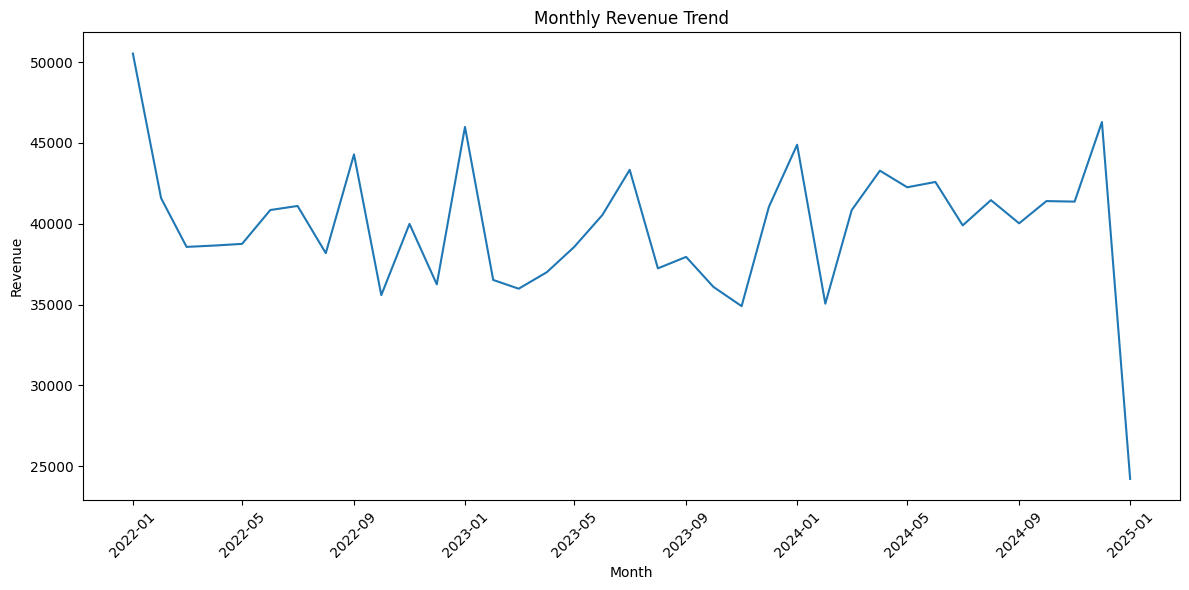

In [14]:
# Revenue by time
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"]
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Finding

Monthly revenue shows considerable volatility rather than a consistent upward
or downward trend. Revenue generally fluctuated between approximately 35,000
and 46,000 during most complete months, with several periods of notable peaks
and declines.

This suggests that overall business revenue is subject to month-to-month
variation, making it important to investigate the underlying drivers of these
changes rather than assuming a sustained growth or decline trend.

The apparent decline in January 2025 should not be interpreted as a true
business downturn because the dataset only contains transactions up to
18 January 2025, making it an incomplete month.

## 5. Sales Volume vs Revenue

Revenue was compared with total quantity sold across categories to determine
whether the highest-revenue categories also sell the greatest number of units.

In [15]:
# Combining revenue and sales volume by category

quantity_by_category = (
    df_clean.groupby("Category")["Quantity"]
    .sum()
    .reset_index(name="Quantity Sold")
)

revenue_vs_quantity = pd.merge(
    category_performance,
    quantity_by_category,
    on="Category"
)

revenue_vs_quantity["Revenue Per Unit Sold"] = (
    revenue_vs_quantity["Revenue"]
    / revenue_vs_quantity["Quantity Sold"]
)

revenue_vs_quantity = revenue_vs_quantity.sort_values(
    "Revenue",
    ascending=False
)

revenue_vs_quantity

,Category,Revenue,Quantity_Sold,Avg_Transaction_Value,Revenue_per_Unit,Quantity Sold,Revenue Per Unit Sold
0,Butchers,197426.0,7774.0,138.934553,25.395678,7774.0,25.395678
1,Electric household essentials,192441.5,7897.0,133.918928,24.368938,7897.0,24.368938
2,Beverages,187978.5,7974.0,131.729853,23.573928,7974.0,23.573928
3,Furniture,186527.0,8083.0,127.758219,23.076457,8083.0,23.076457
4,Food,184645.0,7925.0,129.484572,23.299054,7925.0,23.299054
5,Computers and electric accessories,180902.5,7832.0,129.493558,23.097868,7832.0,23.097868
6,Patisserie,172330.5,7515.0,125.880570,22.931537,7515.0,22.931537
7,Milk Products,170747.5,7889.0,119.822807,21.643744,7889.0,21.643744


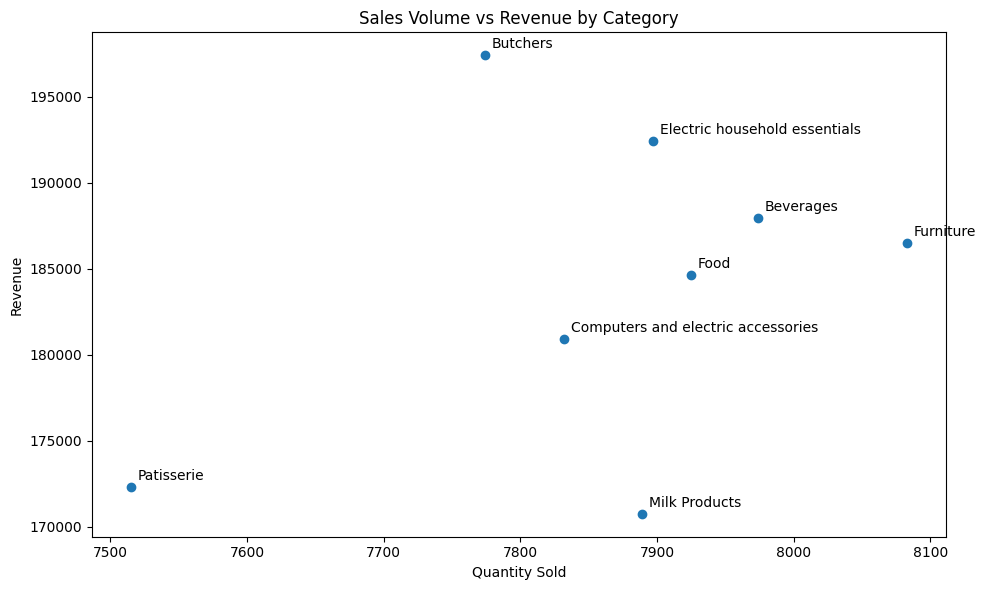

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    revenue_vs_quantity["Quantity Sold"],
    revenue_vs_quantity["Revenue"]
)

for _, row in revenue_vs_quantity.iterrows():
    plt.annotate(
        row["Category"],
        (row["Quantity Sold"], row["Revenue"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Quantity Sold")
plt.ylabel("Revenue")
plt.title("Sales Volume vs Revenue by Category")

plt.tight_layout()
plt.show()

### Finding

Sales volume alone does not explain category revenue performance.

Furniture recorded the highest quantity sold at 8,083 units, yet generated
less revenue than Butchers. Butchers sold 7,774 units but generated the
highest revenue of 197,426.

This indicates that the value generated per unit sold is an important
contributor to revenue performance, in addition to sales volume.

## 6. Butchers Product-Level Analysis

Butchers was identified as the highest-revenue category. A product-level
analysis was therefore conducted to determine whether its performance was
broad-based or concentrated in a small number of products.

In [17]:
# Product-level performance within Butchers

butchers_item_performance = (
    df_clean[df_clean["Category"] == "Butchers"]
    .groupby("Item")
    .agg(
        Quantity_Sold=("Quantity", "sum"),
        Revenue=("Total Spent", "sum"),
        Avg_Price=("Price Per Unit", "mean")
    )
    .reset_index()
)

butchers_item_performance["Revenue_Per_Unit"] = (
    butchers_item_performance["Revenue"]
    / butchers_item_performance["Quantity_Sold"]
)

butchers_item_performance = (
    butchers_item_performance
    .sort_values("Revenue", ascending=False)
)

butchers_item_performance

,Item,Quantity_Sold,Revenue,Avg_Price,Revenue_Per_Unit
16,Item_25_BUT,534.0,21894.0,41.0,41.0
13,Item_22_BUT,540.0,19710.0,36.5,36.5
14,Item_23_BUT,503.0,19114.0,38.0,38.0
11,Item_20_BUT,563.0,18860.5,33.5,33.5
6,Item_16_BUT,448.0,12320.0,27.5,27.5
8,Item_18_BUT,390.0,11895.0,30.5,30.5
5,Item_15_BUT,426.0,11076.0,26.0,26.0
2,Item_12_BUT,496.0,10664.0,21.5,21.5
3,Item_13_BUT,446.0,10258.0,23.0,23.0
12,Item_21_BUT,293.0,10255.0,35.0,35.0


In [18]:
# Top 10 Butchers products by revenue

top_butchers_items = (
    butchers_item_performance
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_butchers_items

,Item,Quantity_Sold,Revenue,Avg_Price,Revenue_Per_Unit
16,Item_25_BUT,534.0,21894.0,41.0,41.0
13,Item_22_BUT,540.0,19710.0,36.5,36.5
14,Item_23_BUT,503.0,19114.0,38.0,38.0
11,Item_20_BUT,563.0,18860.5,33.5,33.5
6,Item_16_BUT,448.0,12320.0,27.5,27.5
8,Item_18_BUT,390.0,11895.0,30.5,30.5
5,Item_15_BUT,426.0,11076.0,26.0,26.0
2,Item_12_BUT,496.0,10664.0,21.5,21.5
3,Item_13_BUT,446.0,10258.0,23.0,23.0
12,Item_21_BUT,293.0,10255.0,35.0,35.0


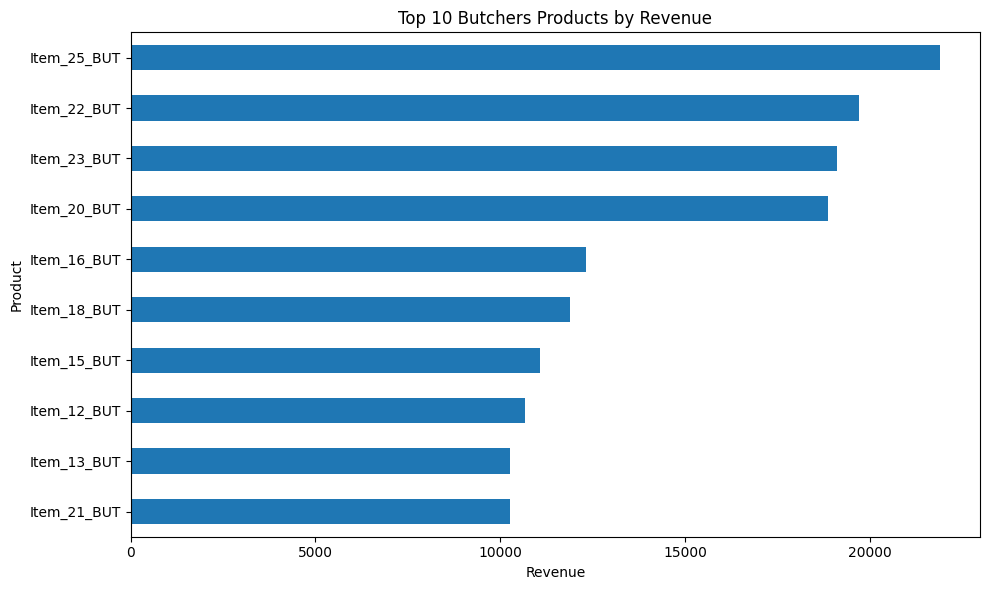

In [19]:
# Top 10 Butchers products by revenue

top_butchers_items.sort_values("Revenue").plot(
    x="Item",
    y="Revenue",
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Butchers Products by Revenue",
    legend=False
)

plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Finding

Revenue within the Butchers category is concentrated among a group of
high-performing products rather than being evenly distributed across all
products.

Item_25_BUT generated the highest revenue at approximately 21,894, followed
by Item_22_BUT at approximately 19,710. Item_23_BUT and Item_20_BUT were also
among the strongest contributors.

This suggests that category-level performance is supported by several
high-performing products, with Item_25_BUT being the strongest individual
contributor.

## 7. Drivers of Revenue Within Butchers

The relationship between product sales volume, average selling price and
revenue was examined to determine whether high-performing Butchers products
are driven primarily by sales volume or price.

In [20]:
# Compare revenue, sales volume and price across Butchers products

butchers_revenue_drivers = (
    df_clean[df_clean["Category"] == "Butchers"]
    .groupby("Item")
    .agg(
        Revenue=("Total Spent", "sum"),
        Quantity_Sold=("Quantity", "sum"),
        Avg_Selling_Price=("Price Per Unit", "mean")
    )
    .reset_index()
)

butchers_revenue_drivers["Revenue_Per_Unit"] = (
    butchers_revenue_drivers["Revenue"]
    / butchers_revenue_drivers["Quantity_Sold"]
)

butchers_revenue_drivers = (
    butchers_revenue_drivers
    .sort_values("Revenue", ascending=False)
)

butchers_revenue_drivers.head(10)

,Item,Revenue,Quantity_Sold,Avg_Selling_Price,Revenue_Per_Unit
16,Item_25_BUT,21894.0,534.0,41.0,41.0
13,Item_22_BUT,19710.0,540.0,36.5,36.5
14,Item_23_BUT,19114.0,503.0,38.0,38.0
11,Item_20_BUT,18860.5,563.0,33.5,33.5
6,Item_16_BUT,12320.0,448.0,27.5,27.5
8,Item_18_BUT,11895.0,390.0,30.5,30.5
5,Item_15_BUT,11076.0,426.0,26.0,26.0
2,Item_12_BUT,10664.0,496.0,21.5,21.5
3,Item_13_BUT,10258.0,446.0,23.0,23.0
12,Item_21_BUT,10255.0,293.0,35.0,35.0


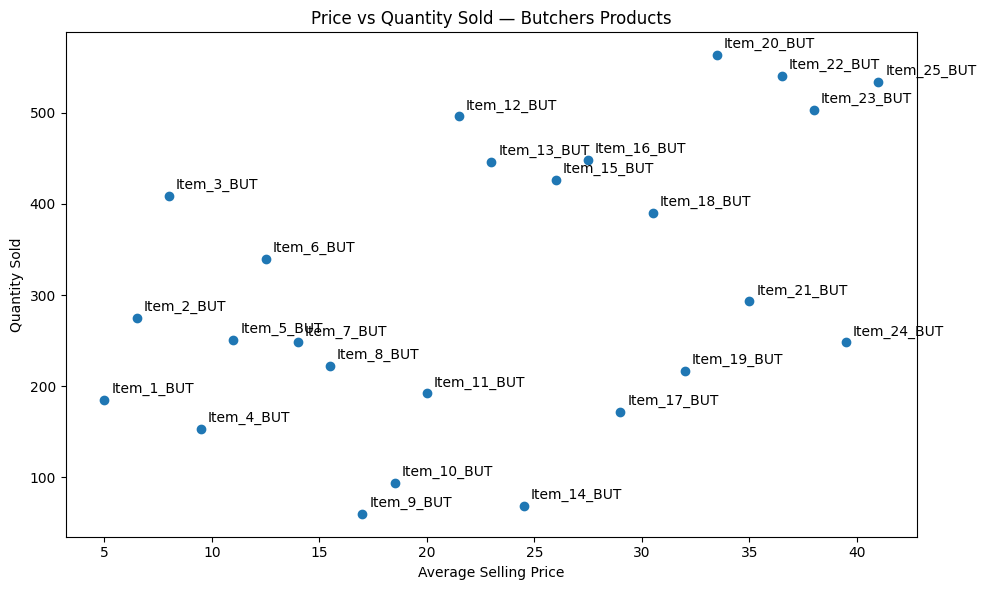

In [21]:
plt.figure(figsize=(10, 6))

plt.scatter(
    butchers_revenue_drivers["Avg_Selling_Price"],
    butchers_revenue_drivers["Quantity_Sold"]
)

for _, row in butchers_revenue_drivers.iterrows():
    plt.annotate(
        row["Item"],
        (row["Avg_Selling_Price"], row["Quantity_Sold"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Average Selling Price")
plt.ylabel("Quantity Sold")
plt.title("Price vs Quantity Sold — Butchers Products")

plt.tight_layout()
plt.show()

### Finding

The relationship between average selling price and quantity sold across
Butchers products appears weak, with the products widely scattered rather
than following a clear linear pattern.

Some products with relatively high selling prices achieve high sales volumes,
while others with similar or lower prices sell considerably fewer units.

This suggests that selling price alone does not explain differences in product
sales volume within the Butchers category. Other factors, such as customer
preferences, product characteristics, availability and purchasing behaviour,
may contribute to differences in demand.

## 8. Impact of Discounts on Sales and Revenue

Discounted and non-discounted transactions were compared to assess whether
discount application is associated with differences in transaction volume,
quantity sold, revenue and average transaction value.

In [22]:
# Compare discounted and non-discounted transactions

discount_analysis = (
    df_clean
    .groupby("Discount Applied")
    .agg(
        Transactions=("Transaction Date", "count"),
        Quantity_Sold=("Quantity", "sum"),
        Revenue=("Total Spent", "sum"),
        Avg_Transaction_Value=("Total Spent", "mean")
    )
    .reset_index()
)

discount_analysis

,Discount Applied,Transactions,Quantity_Sold,Revenue,Avg_Transaction_Value
0,False,3778,21108.0,491632.5,130.130360
1,True,3801,21011.0,496880.5,130.723625


In [23]:
# Calculate percentage difference between discounted and non-discounted groups

no_discount = discount_analysis[
    discount_analysis["Discount Applied"] == False
].iloc[0]

with_discount = discount_analysis[
    discount_analysis["Discount Applied"] == True
].iloc[0]

discount_effect = pd.DataFrame({
    "Metric": [
        "Transactions",
        "Quantity Sold",
        "Revenue",
        "Average Transaction Value"
    ],
    "Percentage Difference": [
        ((with_discount["Transactions"] - no_discount["Transactions"])
         / no_discount["Transactions"]) * 100,

        ((with_discount["Quantity_Sold"] - no_discount["Quantity_Sold"])
         / no_discount["Quantity_Sold"]) * 100,

        ((with_discount["Revenue"] - no_discount["Revenue"])
         / no_discount["Revenue"]) * 100,

        ((with_discount["Avg_Transaction_Value"]
          - no_discount["Avg_Transaction_Value"])
         / no_discount["Avg_Transaction_Value"]) * 100
    ]
})

discount_effect

,Metric,Percentage Difference
0,Transactions,0.608788
1,Quantity Sold,-0.459541
2,Revenue,1.067464
3,Average Transaction Value,0.455901


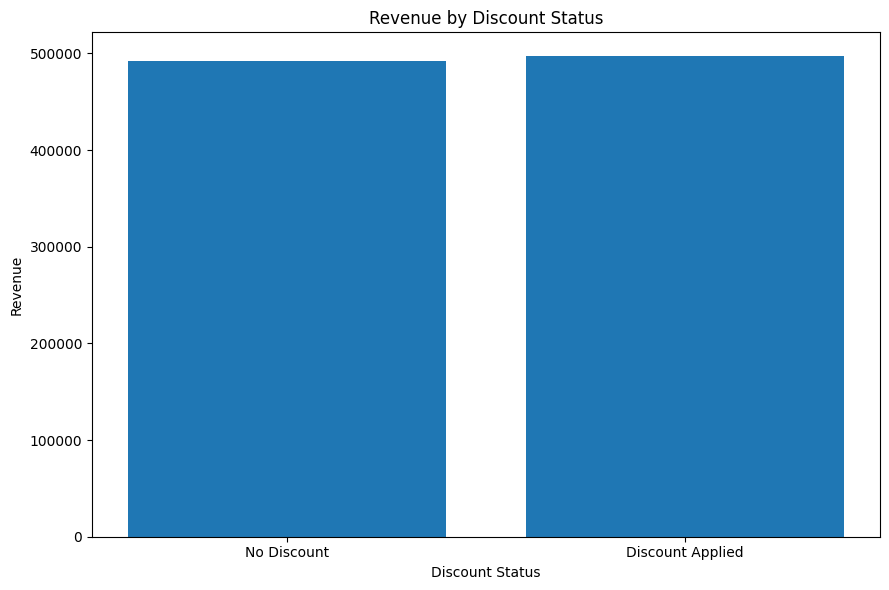

In [24]:
discount_analysis["Discount Status"] = discount_analysis["Discount Applied"].map({
    False: "No Discount",
    True: "Discount Applied"
})

plt.figure(figsize=(9, 6))

plt.bar(
    discount_analysis["Discount Status"],
    discount_analysis["Revenue"]
)

plt.xlabel("Discount Status")
plt.ylabel("Revenue")
plt.title("Revenue by Discount Status")

plt.tight_layout()
plt.show()

### Finding

Discounted transactions generated approximately 1.1% more revenue than
non-discounted transactions. However, the difference was small, while
quantity sold was approximately 0.5% lower for discounted transactions.

The results therefore do not provide strong evidence that discounts materially
improve sales or revenue. Further analysis using discount percentages,
product-level pricing, customer behaviour and profitability data would be
required before making decisions about discount strategy.

## 9. Customer Revenue and Purchase Behaviour

Customer-level transaction data was analyzed to understand customer
contribution to revenue and identify purchasing patterns within the available
data.

In [25]:
# Calculate customer-level performance

customer_performance = (
    df_clean.groupby("Customer ID")
    .agg(
        Transactions=("Transaction Date", "count"),
        Quantity_Sold=("Quantity", "sum"),
        Revenue=("Total Spent", "sum")
    )
    .reset_index()
)

customer_performance["Avg_Transaction_Value"] = (
    customer_performance["Revenue"]
    / customer_performance["Transactions"]
)

customer_performance = customer_performance.sort_values(
    "Revenue",
    ascending=False
)

customer_performance.head(10)

,Customer ID,Transactions,Quantity_Sold,Revenue,Avg_Transaction_Value
23,CUST_24,489,2616.0,64608.0,132.122699
4,CUST_05,497,2686.0,63855.5,128.481891
15,CUST_16,469,2636.0,63185.5,134.723881
12,CUST_13,491,2758.0,63015.5,128.341141
7,CUST_08,480,2734.0,62850.5,130.938542
14,CUST_15,478,2597.0,60749.5,127.091004
9,CUST_10,458,2538.0,60367.5,131.806769
22,CUST_23,450,2522.0,59738.5,132.752222
20,CUST_21,447,2593.0,59639.0,133.420582
1,CUST_02,447,2508.0,59512.5,133.137584


In [26]:
# Overall customer metrics

total_customers = customer_performance["Customer ID"].nunique()

repeat_customers = (
    customer_performance["Transactions"] > 1
).sum()

repeat_customer_rate = (
    repeat_customers / total_customers
) * 100

average_customer_revenue = (
    customer_performance["Revenue"].mean()
)

print("Total Customers:", total_customers)
print("Repeat Customers:", repeat_customers)
print("Repeat Customer Rate:", round(repeat_customer_rate, 2), "%")
print("Average Revenue per Customer:", round(average_customer_revenue, 2))

Total Customers: 25
Repeat Customers: 25
Repeat Customer Rate: 100.0 %
Average Revenue per Customer: 58919.94


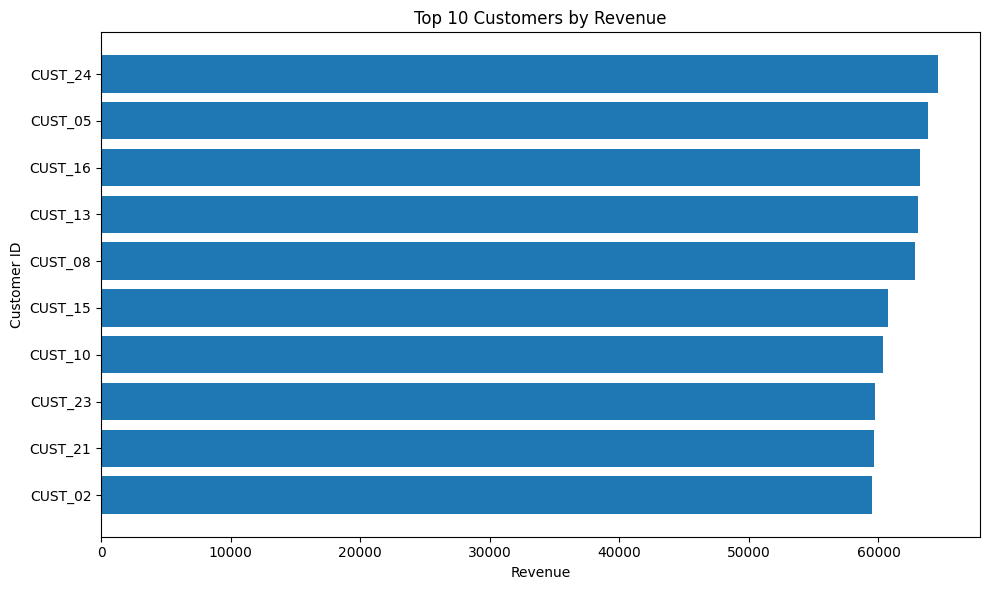

In [27]:
top_customers = (
    customer_performance
    .head(10)
    .sort_values("Revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_customers["Customer ID"].astype(str),
    top_customers["Revenue"]
)

plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.title("Top 10 Customers by Revenue")

plt.tight_layout()
plt.show()

### Finding

Revenue among the top 10 customers is relatively evenly distributed, with
CUST_24 contributing the highest revenue but without a substantial gap over
the other leading customers.

This suggests that, within the top customer segment, revenue is not heavily
dependent on a single dominant customer. However, further customer-level
analysis is required to determine the overall concentration of revenue and
the proportion generated by repeat customers.

# 10. Executive Summary & Key Findings

The analysis was conducted to identify the major drivers of revenue and assess
overall business performance across categories, products, time, discounts and
customers.

## Key Findings

### 1. Butchers is the strongest revenue-generating category

Butchers generated the highest category revenue at 197,426, despite not having
the highest quantity sold. It also recorded the highest average transaction
value (138.93) and revenue per unit (25.40).

This indicates that its revenue performance is not explained by sales volume
alone. The higher value generated per transaction and unit sold appears to be
an important contributor.

### 2. Sales volume alone does not determine revenue

Furniture recorded the highest quantity sold at 8,083 units but generated
less revenue than Butchers.

This demonstrates that a category can sell more units without generating the
highest revenue. Both sales volume and the value generated per unit need to be
considered when evaluating revenue performance.

### 3. Butchers' revenue is supported by several high-performing products

Within Butchers, Item_25_BUT was the highest revenue-generating product at
approximately 21,894, followed by Item_22_BUT and Item_23_BUT.

The category's performance is therefore supported by multiple strong products,
although Item_25_BUT is the leading individual contributor.

### 4. Price alone does not explain product demand

The analysis of average selling price against quantity sold showed no clear
linear relationship among Butchers products.

Some relatively high-priced products achieved high sales volumes, while
others sold considerably fewer units.

Therefore, price alone cannot be used to explain differences in product
demand based on this dataset.

### 5. Discounts show only a marginal difference in performance

Discounted transactions generated approximately 1.1% more revenue than
non-discounted transactions. However, quantity sold was approximately 0.5%
lower, while the number of transactions increased by only about 0.6%.

The differences are small and therefore do not provide strong evidence that
discounting materially improves sales or revenue.

### 6. Revenue varies considerably over time

Monthly revenue fluctuated throughout the period rather than following a
consistent upward or downward trend.

The incomplete January 2025 period should not be interpreted as a major
business decline because the dataset ends on 18 January 2025.

# 11. Business Recommendations

Based on the findings, the following actions are recommended.

### 1. Prioritize Butchers for further investigation

Butchers currently demonstrates the strongest revenue performance. Management
should investigate the products and customer segments contributing to this
performance before making additional investment decisions.

Investment should be guided by profitability and operational capacity rather
than revenue alone.

### 2. Protect and strengthen high-performing Butchers products

Products such as Item_25_BUT and Item_22_BUT should be prioritized for further
investigation to understand what is driving their performance.

Management should assess their profitability, stock availability and customer
demand before increasing their allocation or promotional support.

### 3. Investigate the drivers of lower-performing categories

Categories generating lower revenue should not automatically be considered
poor performers.

Their performance should be assessed alongside quantity sold, pricing,
product mix, customer demand, inventory availability and profitability to
identify specific opportunities for improvement.

### 4. Avoid relying on discounts as the primary growth strategy

Because discounted and non-discounted transactions showed only marginal
differences in revenue and quantity sold, discounting should be targeted
rather than applied broadly.

Promotions should ideally be evaluated at product and customer-segment level.

### 5. Improve revenue monitoring

Management should monitor revenue, quantity sold, average transaction value
and revenue per unit over time.

This would help identify meaningful changes in performance and investigate
the causes of significant monthly fluctuations.

# 12. Limitations & Additional Data Required

The current dataset provides useful information about transactions, revenue,
products, categories and customers. However, it does not contain enough
information to determine profitability or fully explain customer and
operational behaviour.

The following additional datasets would strengthen the analysis.

### Cost Data

Cost of goods sold and other relevant costs would allow gross profit and
profit margin to be calculated.

This is particularly important for Butchers because high revenue does not
necessarily mean high profitability.

### Inventory Data

Inventory levels, stock-outs, replenishment dates and inventory turnover
would help determine whether sales performance is affected by product
availability.

This would also help identify fast-moving, slow-moving and potentially
overstocked products.

### Customer Behaviour Data

Additional customer information such as purchase frequency, customer
segments, demographics, acquisition source and purchasing preferences would
help explain why customers purchase particular products.

The current dataset allows basic customer-level analysis through Customer ID,
but richer behavioural information is unavailable.

### Discount & Promotion Data

The current dataset indicates whether a discount was applied, but does not
provide sufficient detail about the size, type or duration of each discount.

Discount percentage, promotional campaign, product-level pricing and campaign
dates would allow a more robust assessment of promotional effectiveness.

### Competitor / Market Data

Competitor pricing and market-level information could help determine whether
changes in sales or revenue are influenced by external market conditions.